# Latest GW Player Picker Dashboard

Use this notebook to shortlist players by position, inspect predicted points, and generate plots you can share with your league group.

In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.append(str(Path('../..').resolve()))
from latest_gw_tools import load_latest_outputs, load_gw_outputs
from squad_selection import get_best_11, get_best_11_noadj, get_owner_dict

sns.set_theme(style='whitegrid')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)

In [3]:
# Leave TARGET_GW as None to auto-load latest available GW output.
TARGET_GW = 3
TOP_N = 20
BACKTEST_YEAR = 26
EXPORT_FIGURES = False
FIG_DIR = Path('..') / 'figures'

if EXPORT_FIGURES:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
if TARGET_GW is None:
    latest_gw, pred_simple, pred_full, fixture_difficulty = load_latest_outputs(predictions_dir='../predictions', fixture_dir='../fixture_difficulty')
else:
    latest_gw = TARGET_GW
    pred_simple, pred_full, fixture_difficulty = load_gw_outputs(TARGET_GW, predictions_dir='../predictions', fixture_dir='../fixture_difficulty')

print(f'Loaded GW: {latest_gw}')
print(f'Players in simple output: {len(pred_simple):,}')
print(f'Players in full output: {len(pred_full):,}')

Loaded GW: 3
Players in simple output: 627
Players in full output: 627


In [5]:
df = pred_simple.copy()
if 'predicted_points_adj' not in df.columns:
    df['predicted_points_adj'] = df['predicted_points']

owner_dict = get_owner_dict()
owner_name_map = {str(int(k)): v for k, v in owner_dict.items()}
df['owner_name'] = df['owner'].fillna(-1).astype(int).astype(str).map(owner_name_map).fillna('Free Agent')

# Combine duplicate player rows (e.g., double gameweeks) into one row per player/team/position/owner.
group_cols = ['full_name', 'team', 'position', 'owner_name']
for col in ['predicted_points', 'predicted_points_adj', 'fixture_diff_index']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

agg_dict = {
    'predicted_points': 'sum',
    'predicted_points_adj': 'sum',
}
if 'fixture_diff_index' in df.columns:
    agg_dict['fixture_diff_index'] = 'mean'

df = (
    df.groupby(group_cols, as_index=False)
    .agg(agg_dict)
)

# --- Multi-GW horizon means: mean predicted points (adjusted) over the next 3/6
# GWs starting at latest_gw. A blank GW for a player is excluded from their
# average (not counted as zero) -- matches the horizon methodology in WORKFLOW.md.
predictions_dir = Path('..') / 'predictions'

def load_horizon_mean_adj(start_gw, n_gws, predictions_dir=predictions_dir):
    frames = []
    for gw in range(start_gw, start_gw + n_gws):
        path = predictions_dir / f'predicted_gw{gw}_simple.csv'
        if not path.exists():
            break
        gw_df = pd.read_csv(path)
        if 'predicted_points_adj' not in gw_df.columns:
            gw_df['predicted_points_adj'] = gw_df['predicted_points']
        # Combine double-gameweek duplicates within this GW before averaging across GWs.
        gw_df = (
            gw_df.groupby(['full_name', 'team', 'position'], as_index=False)
            [['predicted_points_adj']].sum()
        )
        frames.append(gw_df)
    if not frames:
        return pd.DataFrame(columns=['full_name', 'team', 'position', 'predicted_points_adj'])
    return (
        pd.concat(frames, ignore_index=True)
        .groupby(['full_name', 'team', 'position'], as_index=False)
        .mean(numeric_only=True)
    )

horizon_3gw = load_horizon_mean_adj(latest_gw, 3).rename(columns={'predicted_points_adj': 'predicted_points_adj_3gw'})
horizon_6gw = load_horizon_mean_adj(latest_gw, 6).rename(columns={'predicted_points_adj': 'predicted_points_adj_6gw'})

df = df.merge(horizon_3gw, on=['full_name', 'team', 'position'], how='left')
df = df.merge(horizon_6gw, on=['full_name', 'team', 'position'], how='left')

rank_col = 'predicted_points_adj'
df_sorted = df.sort_values(rank_col, ascending=False).reset_index(drop=True)
df_sorted.head(10)

,full_name,team,position,owner_name,predicted_points,predicted_points_adj,fixture_diff_index,predicted_points_adj_3gw,predicted_points_adj_6gw
0,bukayo_saka,Arsenal,MID,Arthur,5.165318,8.926271,1.728116,7.107086,6.742114
1,cody_gakpo,Liverpool,MID,Rory D,4.316140,8.036667,1.862003,6.523323,5.297302
2,james_tarkowski,Everton,DEF,Marcus,3.962188,7.924376,2.000000,7.490084,6.677743
3,dominic_calvert_lewin,Leeds,FWD,Arthur,3.908525,7.817051,2.000000,5.913534,5.174876
4,rayan_cherki,Man City,MID,Marcus,4.822185,7.807617,1.619104,6.011889,7.573070
5,dominik_szoboszlai,Liverpool,MID,Rory D,4.151391,7.729905,1.862003,6.274325,5.095102
6,bruno_borges_fernandes,Man Utd,MID,Lucas,7.218612,7.481240,1.036382,9.155660,8.859484
7,marc_guehi,Man City,DEF,Dave,3.656438,7.312876,2.000000,6.676736,6.006533
8,antoine_semenyo,Man City,MID,Dave,4.478795,7.251633,1.619104,5.583780,7.033788
9,gonzalo_garcia,Fulham,FWD,Marcus,3.566374,7.132747,2.000000,4.309141,3.539558


In [6]:
## Position Shortlists

In [7]:
show_cols = ['full_name', 'team', 'owner_name', 'predicted_points', 'predicted_points_adj',
             'predicted_points_adj_3gw', 'predicted_points_adj_6gw', 'fixture_diff_index']
position_lists = {}

for pos in ['GK', 'DEF', 'MID', 'FWD']:
    pos_df = (
        df_sorted
        .query('position == @pos')
        .loc[:, show_cols]
        .head(TOP_N)
        .reset_index(drop=True)
    )
    position_lists[pos] = pos_df
    print(f'\nTop {TOP_N} {pos}')
    display(pos_df)


Top 20 GK


,full_name,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,jordan_pickford,Everton,Marcus,3.397480,6.794961,6.039965,5.033304,2.000000
1,konstantinos_tzolakis,Hull City,Free Agent,3.305421,6.610841,6.365995,6.488418,2.000000
2,caoimhin_kelleher,Brentford,Dave,3.153644,6.307288,5.045830,4.625344,2.000000
3,lukas_hornicek,Newcastle,Doug,3.114636,6.229271,4.660418,5.444844,2.000000
4,gianluigi_donnarumma,Man City,Lucas,3.073102,6.146204,4.370634,3.516994,2.000000
5,matz_sels,Nott'm Forest,Arthur,3.014780,5.627590,5.493600,3.718229,1.866667
6,james_trafford,Leeds,Arthur,3.182780,5.092448,5.516819,5.729004,1.600000
7,robin_roefs,Sunderland,Rory D,3.078018,4.788029,3.511221,3.830423,1.555556
8,bernd_leno,Fulham,Marcus,2.846895,4.428504,3.848581,3.505899,1.555556
9,david_raya_martin,Arsenal,Doug,3.513331,3.747553,5.465182,6.245922,1.066667



Top 20 DEF


,full_name,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,james_tarkowski,Everton,Marcus,3.962188,7.924376,7.490084,6.677743,2.000000
1,marc_guehi,Man City,Dave,3.656438,7.312876,6.676736,6.006533,2.000000
2,lewis_hall,Newcastle,Marcus,3.501200,7.002400,6.684677,6.843539,2.000000
3,josko_gvardiol,Man City,Will,3.429708,6.859416,6.262722,5.634077,2.000000
4,nathan_collins,Brentford,Doug,3.347845,6.695691,5.564795,6.127141,2.000000
5,ruben_dos_santos_gato_alves_dias,Man City,Rory B,3.336267,6.672534,6.092097,5.480579,2.000000
6,jarrad_branthwaite,Everton,Tobias,3.287293,6.574586,6.214268,5.540297,2.000000
7,michael_kayode,Brentford,Rory B,3.215451,6.430902,5.344729,5.884836,2.000000
8,kristoffer_ajer,Brentford,Free Agent,3.066272,6.132545,5.096764,5.611814,2.000000
9,amar_dedic,Newcastle,Free Agent,3.051054,6.102107,5.825235,5.963671,2.000000



Top 20 MID


,full_name,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,bukayo_saka,Arsenal,Arthur,5.165318,8.926271,7.107086,6.742114,1.728116
1,cody_gakpo,Liverpool,Rory D,4.316140,8.036667,6.523323,5.297302,1.862003
2,rayan_cherki,Man City,Marcus,4.822185,7.807617,6.011889,7.573070,1.619104
3,dominik_szoboszlai,Liverpool,Rory D,4.151391,7.729905,6.274325,5.095102,1.862003
4,bruno_borges_fernandes,Man Utd,Lucas,7.218612,7.481240,9.155660,8.859484,1.036382
5,antoine_semenyo,Man City,Dave,4.478795,7.251633,5.583780,7.033788,1.619104
6,phil_foden,Man City,Lucas,4.347959,7.039795,5.420664,6.828314,1.619104
7,florian_wirtz,Liverpool,Tobias,3.667024,6.828011,5.542263,4.500626,1.862003
8,morgan_gibbs_white,Nott'm Forest,Will,4.300243,6.645651,6.497169,6.177704,1.545413
9,victor_munoz,Liverpool,Free Agent,3.328105,6.196943,5.030028,4.084663,1.862003



Top 20 FWD


,full_name,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,dominic_calvert_lewin,Leeds,Arthur,3.908525,7.817051,5.913534,5.174876,2.000000
1,gonzalo_garcia,Fulham,Marcus,3.566374,7.132747,4.309141,3.539558,2.000000
2,joao_pedro_junqueira_de_jesus,Chelsea,Tobias,4.967656,6.420969,7.681332,7.971198,1.292555
3,erling_haaland,Man City,Rory D,5.555422,6.409357,9.156224,8.428815,1.153712
4,alexander_isak,Liverpool,Marcus,4.407126,5.827241,5.693010,5.962636,1.322232
5,brian_brobbey,Sunderland,Free Agent,2.708342,4.993156,3.454642,3.346905,1.843621
6,thierno_barry,Everton,Will,3.386794,4.967333,5.245044,4.466754,1.466677
7,kai_havertz,Arsenal,Doug,3.921644,4.307615,4.883070,3.793263,1.098421
8,yoane_wissa,Newcastle,Will,4.145305,3.614605,4.097809,5.064924,0.871976
9,wilson_isidor,Sunderland,Rory B,1.944470,3.584866,2.480280,2.402930,1.843621


In [8]:
show_cols = ['full_name', 'team', 'position', 'owner_name', 'predicted_points', 'predicted_points_adj',
             'predicted_points_adj_3gw', 'predicted_points_adj_6gw', 'fixture_diff_index']
positions = ['GK', 'DEF', 'MID', 'FWD']

for pos in positions:
    doug_pos = (
        df_sorted
        .query('position == @pos and owner_name == "Doug"')
        .loc[:, show_cols]
    )

    free_agent_pos = (
        df_sorted
        .query('position == @pos and owner_name == "Free Agent"')
        .loc[:, show_cols]
        .head(20)
    )

    combined_pos = pd.concat([doug_pos, free_agent_pos], ignore_index=True)

    print(f'\n{pos}: Doug + Top Free Agents')
    display(combined_pos)



GK: Doug + Top Free Agents


,full_name,team,position,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,lukas_hornicek,Newcastle,GK,Doug,3.114636,6.229271,4.660418,5.444844,2.000000
1,david_raya_martin,Arsenal,GK,Doug,3.513331,3.747553,5.465182,6.245922,1.066667
2,konstantinos_tzolakis,Hull City,GK,Free Agent,3.305421,6.610841,6.365995,6.488418,2.000000
3,kjell_scherpen,Ipswich Town,GK,Free Agent,2.899834,1.449917,2.545410,2.991125,0.500000
4,geronimo_rulli,Man City,GK,Free Agent,0.544397,1.088795,0.774254,0.623032,2.000000
5,nick_pope,Newcastle,GK,Free Agent,0.542813,1.085627,0.812210,0.948918,2.000000
6,mark_travers,Everton,GK,Free Agent,0.542021,1.084043,0.963593,0.802994,2.000000
7,robert_lynch_sanchez,Chelsea,GK,Free Agent,1.574721,0.839851,1.026485,1.551392,0.533333
8,marcus_bettinelli,Man City,GK,Free Agent,0.393098,0.786196,0.559073,0.449879,2.000000
9,mark_gillespie,Newcastle,GK,Free Agent,0.391514,0.783028,0.585821,0.684425,2.000000



DEF: Doug + Top Free Agents


,full_name,team,position,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,nathan_collins,Brentford,DEF,Doug,3.347845,6.695691,5.564795,6.127141,2.000000
1,nico_o'reilly,Man City,DEF,Doug,2.956328,5.912656,5.398320,4.856443,2.000000
2,nikola_milenkovic,Nott'm Forest,DEF,Doug,2.755665,5.511330,5.511330,4.119577,2.000000
3,abdukodir_khusanov,Man City,DEF,Doug,2.726556,5.453112,4.978751,4.478989,2.000000
4,gabriel_dos_santos_magalhaes,Arsenal,DEF,Doug,3.975177,5.036538,5.514210,6.732282,1.266997
5,kristoffer_ajer,Brentford,DEF,Free Agent,3.066272,6.132545,5.096764,5.611814,2.000000
6,amar_dedic,Newcastle,DEF,Free Agent,3.051054,6.102107,5.825235,5.963671,2.000000
7,semi_ajayi,Hull City,DEF,Free Agent,3.047344,6.094689,4.428865,5.261777,2.000000
8,john_egan,Hull City,DEF,Free Agent,2.968166,5.936332,4.313791,5.125062,2.000000
9,vitalii_mykolenko,Everton,DEF,Free Agent,2.784502,5.569004,5.263797,4.692909,2.000000



MID: Doug + Top Free Agents


,full_name,team,position,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,martin_odegaard,Arsenal,MID,Doug,3.493054,6.036404,4.806178,4.559365,1.728116
1,diego_gomez_amarilla,Brighton,MID,Doug,4.000059,5.765342,5.678904,6.513444,1.441314
2,vitaly_janelt,Brentford,MID,Doug,3.401033,3.871123,4.448440,4.717825,1.138220
3,marcus_rashford,Man Utd,MID,Doug,3.332557,3.453802,4.226818,4.090085,1.036382
4,emiliano_buendia_stati,Aston Villa,MID,Doug,2.935643,1.467822,1.508749,1.488285,0.500000
5,victor_munoz,Liverpool,MID,Free Agent,3.328105,6.196943,5.030028,4.084663,1.862003
6,dan_ndoye,Nott'm Forest,MID,Free Agent,3.409284,5.268751,5.151033,4.897757,1.545413
7,myles_lewis_skelly,Arsenal,MID,Free Agent,2.710295,4.683706,3.729161,3.537656,1.728116
8,julio_enciso,Ipswich Town,MID,Free Agent,3.608383,4.656393,4.278915,4.084420,1.290438
9,james_mcatee,Nott'm Forest,MID,Free Agent,2.835317,4.381736,4.283836,4.073200,1.545413



FWD: Doug + Top Free Agents


,full_name,team,position,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,kai_havertz,Arsenal,FWD,Doug,3.921644,4.307615,4.883070,3.793263,1.098421
1,omar_marmoush,Spurs,FWD,Doug,2.653354,1.470727,1.399147,1.560616,0.554290
2,georginio_rutter,Brighton,FWD,Doug,1.883919,1.322866,1.394027,2.011001,0.702188
3,brian_brobbey,Sunderland,FWD,Free Agent,2.708342,4.993156,3.454642,3.346905,1.843621
4,emersonn_correia_da_silva,Ipswich Town,FWD,Free Agent,2.855508,3.285380,4.432438,4.577602,1.150541
5,eddie_nketiah,Crystal Palace,FWD,Free Agent,2.668468,3.275064,2.158677,1.999775,1.227320
6,lukas_nmecha,Leeds,FWD,Free Agent,1.419019,2.838039,2.146953,1.878778,2.000000
7,jorgen_strand_larsen,Crystal Palace,FWD,Free Agent,2.152093,2.641307,1.740952,1.612799,1.227320
8,chuba_akpom,Ipswich Town,FWD,Free Agent,1.985368,2.284248,3.081771,3.182700,1.150541
9,charalampos_kostoulas,Brighton,FWD,Free Agent,2.692848,1.890886,1.992603,2.874497,0.702188


In [9]:
# A compact shortlist view you can screenshot/share.
shortlist = pd.concat(
    [
        position_lists[pos].assign(position=pos)
        for pos in ['GK', 'DEF', 'MID', 'FWD']
    ],
    ignore_index=True,
)

shortlist = shortlist[[
    'position', 'full_name', 'team', 'owner_name',
    'predicted_points', 'predicted_points_adj',
    'predicted_points_adj_3gw', 'predicted_points_adj_6gw',
    'fixture_diff_index'
 ]]
shortlist.head(40)

,position,full_name,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,GK,jordan_pickford,Everton,Marcus,3.397480,6.794961,6.039965,5.033304,2.000000
1,GK,konstantinos_tzolakis,Hull City,Free Agent,3.305421,6.610841,6.365995,6.488418,2.000000
2,GK,caoimhin_kelleher,Brentford,Dave,3.153644,6.307288,5.045830,4.625344,2.000000
3,GK,lukas_hornicek,Newcastle,Doug,3.114636,6.229271,4.660418,5.444844,2.000000
4,GK,gianluigi_donnarumma,Man City,Lucas,3.073102,6.146204,4.370634,3.516994,2.000000
5,GK,matz_sels,Nott'm Forest,Arthur,3.014780,5.627590,5.493600,3.718229,1.866667
6,GK,james_trafford,Leeds,Arthur,3.182780,5.092448,5.516819,5.729004,1.600000
7,GK,robin_roefs,Sunderland,Rory D,3.078018,4.788029,3.511221,3.830423,1.555556
8,GK,bernd_leno,Fulham,Marcus,2.846895,4.428504,3.848581,3.505899,1.555556
9,GK,david_raya_martin,Arsenal,Doug,3.513331,3.747553,5.465182,6.245922,1.066667


In [10]:
## Team Selection Helpers

In [11]:
formation_adj, best_11_adj = get_best_11(df_sorted)
formation_raw, best_11_raw = get_best_11_noadj(df_sorted)

print(f'Best XI (adj) formation: {formation_adj}')
display(best_11_adj[['full_name', 'position', 'team', 'owner_name', 'predicted_points', 'predicted_points_adj']])

print(f'Best XI (raw) formation: {formation_raw}')
display(best_11_raw[['full_name', 'position', 'team', 'owner_name', 'predicted_points']])

Best XI (adj) formation: {'GK': 1, 'DEF': 3, 'MID': 5, 'FWD': 2}


,full_name,position,team,owner_name,predicted_points,predicted_points_adj
4,bukayo_saka,MID,Arsenal,Arthur,5.165318,8.926271
5,cody_gakpo,MID,Liverpool,Rory D,4.316140,8.036667
1,james_tarkowski,DEF,Everton,Marcus,3.962188,7.924376
9,dominic_calvert_lewin,FWD,Leeds,Arthur,3.908525,7.817051
6,rayan_cherki,MID,Man City,Marcus,4.822185,7.807617
7,dominik_szoboszlai,MID,Liverpool,Rory D,4.151391,7.729905
8,bruno_borges_fernandes,MID,Man Utd,Lucas,7.218612,7.481240
2,marc_guehi,DEF,Man City,Dave,3.656438,7.312876
10,gonzalo_garcia,FWD,Fulham,Marcus,3.566374,7.132747
3,lewis_hall,DEF,Newcastle,Marcus,3.501200,7.002400


Best XI (raw) formation: {'GK': 1, 'DEF': 3, 'MID': 5, 'FWD': 2}


,full_name,position,team,owner_name,predicted_points
4,bruno_borges_fernandes,MID,Man Utd,Lucas,7.218612
9,erling_haaland,FWD,Man City,Rory D,5.555422
5,cole_palmer,MID,Chelsea,Richard,5.347239
6,bryan_mbeumo,MID,Man Utd,Rory B,5.186612
7,bukayo_saka,MID,Arsenal,Arthur,5.165318
10,joao_pedro_junqueira_de_jesus,FWD,Chelsea,Tobias,4.967656
8,morgan_rogers,MID,Chelsea,Dave,4.924905
1,gabriel_dos_santos_magalhaes,DEF,Arsenal,Doug,3.975177
2,james_tarkowski,DEF,Everton,Marcus,3.962188
3,riccardo_calafiori,DEF,Arsenal,Richard,3.821486


In [12]:
doug_pool = df_sorted.query('owner_name == "Doug"').copy()
doug_formation, doug_best_11 = get_best_11(doug_pool)

print(f"Doug Best XI formation: {doug_formation['DEF']}-{doug_formation['MID']}-{doug_formation['FWD']}")
display(
    doug_best_11[
        ['full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'fixture_diff_index']
    ].sort_values(['position', 'predicted_points_adj'], ascending=[True, False]).reset_index(drop=True)
)

bench_key_cols = ['full_name', 'team', 'position']
bench_keys = set(
    tuple(row) for row in doug_best_11[bench_key_cols].drop_duplicates().itertuples(index=False, name=None)
)
bench_players = (
    doug_pool[
        ~doug_pool[bench_key_cols].apply(tuple, axis=1).isin(bench_keys)
    ][['full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'fixture_diff_index']]
    .sort_values('predicted_points_adj', ascending=False)
    .reset_index(drop=True)
)

print('Doug Bench Players:')
display(bench_players)

Doug Best XI formation: 5-4-1


,full_name,position,team,predicted_points,predicted_points_adj,fixture_diff_index
0,nathan_collins,DEF,Brentford,3.347845,6.695691,2.000000
1,nico_o'reilly,DEF,Man City,2.956328,5.912656,2.000000
2,nikola_milenkovic,DEF,Nott'm Forest,2.755665,5.511330,2.000000
3,abdukodir_khusanov,DEF,Man City,2.726556,5.453112,2.000000
4,gabriel_dos_santos_magalhaes,DEF,Arsenal,3.975177,5.036538,1.266997
5,kai_havertz,FWD,Arsenal,3.921644,4.307615,1.098421
6,lukas_hornicek,GK,Newcastle,3.114636,6.229271,2.000000
7,martin_odegaard,MID,Arsenal,3.493054,6.036404,1.728116
8,diego_gomez_amarilla,MID,Brighton,4.000059,5.765342,1.441314
9,vitaly_janelt,MID,Brentford,3.401033,3.871123,1.138220


Doug Bench Players:


,full_name,position,team,predicted_points,predicted_points_adj,fixture_diff_index
0,david_raya_martin,GK,Arsenal,3.513331,3.747553,1.066667
1,omar_marmoush,FWD,Spurs,2.653354,1.470727,0.554290
2,emiliano_buendia_stati,MID,Aston Villa,2.935643,1.467822,0.500000
3,georginio_rutter,FWD,Brighton,1.883919,1.322866,0.702188


In [13]:
owner_summary_rows = []
fa_formation = None
fa_best_11 = pd.DataFrame()

for owner_name in sorted(df_sorted['owner_name'].unique()):
    if owner_name == 'Free Agent':
        continue
    owner_df = df_sorted.query('owner_name == @owner_name').copy()
    if owner_df.empty:
        continue
    owner_formation, owner_best_11 = get_best_11(owner_df)
    owner_summary_rows.append({
        'owner_name': owner_name,
        'formation': f"{owner_formation['DEF']}-{owner_formation['MID']}-{owner_formation['FWD']}",
        'predicted_points_adj_sum': owner_best_11['predicted_points_adj'].sum(),
        'predicted_points_sum': owner_best_11['predicted_points'].sum(),
    })

# Add and show the best XI that can be built from free agents only.
free_agent_df = df_sorted.query('owner_name == "Free Agent"').copy()
if not free_agent_df.empty:
    fa_formation, fa_best_11 = get_best_11(free_agent_df)
    owner_summary_rows.append({
        'owner_name': 'Free Agent XI',
        'formation': f"{fa_formation['DEF']}-{fa_formation['MID']}-{fa_formation['FWD']}",
        'predicted_points_adj_sum': fa_best_11['predicted_points_adj'].sum(),
        'predicted_points_sum': fa_best_11['predicted_points'].sum(),
    })

owner_summary = pd.DataFrame(owner_summary_rows).sort_values('predicted_points_adj_sum', ascending=False)
display(owner_summary)

if fa_best_11.empty:
    print('No Free Agent XI available for this GW.')
else:
    print(f"Free Agent XI formation: {fa_formation['DEF']}-{fa_formation['MID']}-{fa_formation['FWD']}")
    display(
        fa_best_11[
            ['full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'fixture_diff_index']
        ].sort_values(['position', 'predicted_points_adj'], ascending=[True, False]).reset_index(drop=True)
    )

,owner_name,formation,predicted_points_adj_sum,predicted_points_sum
10,Free Agent XI,5-4-1,62.244469,33.987168
4,Marcus,3-5-2,60.933330,40.932876
2,Doug,5-4-1,58.272884,37.024554
9,Will,4-4-2,53.000332,37.338172
7,Rory D,5-4-1,49.954752,37.654348
0,Arthur,4-4-2,43.736158,31.748597
8,Tobias,4-4-2,42.568014,37.741112
1,Dave,5-4-1,40.869210,30.499454
3,Lucas,4-5-1,38.812807,37.478361
6,Rory B,3-4-3,38.609576,29.481042


Free Agent XI formation: 5-4-1


,full_name,position,team,predicted_points,predicted_points_adj,fixture_diff_index
0,kristoffer_ajer,DEF,Brentford,3.066272,6.132545,2.000000
1,amar_dedic,DEF,Newcastle,3.051054,6.102107,2.000000
2,semi_ajayi,DEF,Hull City,3.047344,6.094689,2.000000
3,john_egan,DEF,Hull City,2.968166,5.936332,2.000000
4,vitalii_mykolenko,DEF,Everton,2.784502,5.569004,2.000000
5,brian_brobbey,FWD,Sunderland,2.708342,4.993156,1.843621
6,konstantinos_tzolakis,GK,Hull City,3.305421,6.610841,2.000000
7,victor_munoz,MID,Liverpool,3.328105,6.196943,1.862003
8,dan_ndoye,MID,Nott'm Forest,3.409284,5.268751,1.545413
9,myles_lewis_skelly,MID,Arsenal,2.710295,4.683706,1.728116


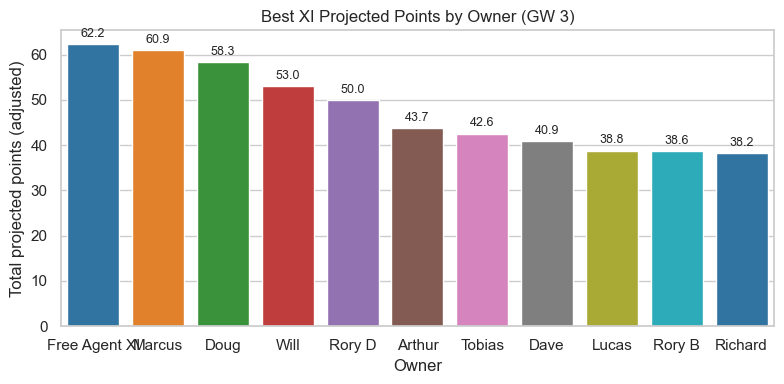

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_owner_summary = owner_summary.copy()

sns.barplot(
    data=plot_owner_summary,
    x='owner_name',
    y='predicted_points_adj_sum',
    hue='owner_name',
    legend=False,
    ax=ax,
    palette='tab10',
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)

ax.set_title(f'Best XI Projected Points by Owner (GW {latest_gw})')
ax.set_xlabel('Owner')
ax.set_ylabel('Total projected points (adjusted)')
plt.xticks(rotation=0)
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'owner_best_xi_gw{latest_gw}.png', dpi=200)

## Season Trajectory: Cumulative Points by Owner

In [15]:
import requests

def get_current_gw():
    """Real 'as of today' gameweek from the draft league's bootstrap-static feed --
    distinct from latest_gw above, which reflects the prediction-file horizon
    (TARGET_GW=None resolves to end of season, see WORKFLOW.md), not the calendar."""
    resp = requests.get('https://draft.premierleague.com/api/bootstrap-static', timeout=20)
    resp.raise_for_status()
    return resp.json()['events']['current']

def load_owner_actual_points(league_id=3875):
    """Real points each owner has already scored, from the draft league's H2H
    matches (each owner appears in exactly one match per GW; the match points are
    that owner's actual scored total for the week, independent of win/loss). Only
    includes GWs that have started or finished -- future GWs are 0-0 placeholders
    in this feed, and the current GW's points update live as matches are played."""
    resp = requests.get(f'https://draft.premierleague.com/api/league/{league_id}/details', timeout=20)
    resp.raise_for_status()
    data = resp.json()

    entry_id_by_league_entry_id = {entry['id']: entry['entry_id'] for entry in data['league_entries']}
    owner_dict = get_owner_dict()

    rows = []
    for match in data['matches']:
        if not (match['started'] or match['finished']):
            continue
        for side in ('1', '2'):
            entry_id = entry_id_by_league_entry_id.get(match[f'league_entry_{side}'])
            owner_name = owner_dict.get(float(entry_id)) if entry_id is not None else None
            if owner_name is None:
                continue
            rows.append({
                'gw': match['event'],
                'owner_name': owner_name,
                'actual_points': match[f'league_entry_{side}_points'],
            })
    return pd.DataFrame(rows)

current_gw = get_current_gw()
actual_points_df = load_owner_actual_points()

print(f'Real current GW: {current_gw}')
display(actual_points_df.sort_values(['owner_name', 'gw']).head(10))

Real current GW: 3


,gw,owner_name,actual_points
2,1,Arthur,51
17,2,Arthur,40
20,3,Arthur,0
8,1,Dave,35
11,2,Dave,23
26,3,Dave,1
7,1,Doug,44
14,2,Doug,34
29,3,Doug,0
1,1,Lucas,29


In [16]:
END_GW = 38  # season length (league stop_event)

def load_owner_projected_points(current_gw, end_gw=END_GW, predictions_dir=Path('..') / 'predictions'):
    """Best-XI (adjusted) projected total per owner for each future GW -- repeats
    the single-GW 'Best XI by Owner' logic above (get_best_11 on each owner's pool)
    once per remaining GW, reading that GW's own prediction file each time."""
    owner_dict = get_owner_dict()
    owner_name_map = {str(int(k)): v for k, v in owner_dict.items()}

    rows = []
    for gw in range(current_gw + 1, end_gw + 1):
        path = predictions_dir / f'predicted_gw{gw}_simple.csv'
        if not path.exists():
            continue
        gw_df = pd.read_csv(path)
        if 'predicted_points_adj' not in gw_df.columns:
            gw_df['predicted_points_adj'] = gw_df['predicted_points']
        gw_df['owner_name'] = gw_df['owner'].fillna(-1).astype(int).astype(str).map(owner_name_map).fillna('Free Agent')

        for owner_name in owner_dict.values():
            owner_pool = gw_df.query('owner_name == @owner_name')
            if owner_pool.empty:
                continue
            _, owner_best_11 = get_best_11(owner_pool)
            rows.append({
                'gw': gw,
                'owner_name': owner_name,
                'projected_points': owner_best_11['predicted_points_adj'].sum(),
            })
    return pd.DataFrame(rows)

projected_points_df = load_owner_projected_points(current_gw)
projected_points_df.sort_values(['owner_name', 'gw']).head(10)

,gw,owner_name,projected_points
7,4,Arthur,32.771830
17,5,Arthur,48.340207
27,6,Arthur,37.248823
37,7,Arthur,42.147092
47,8,Arthur,41.248667
57,9,Arthur,43.079792
67,10,Arthur,38.021237
77,11,Arthur,37.717150
87,12,Arthur,40.372723
97,13,Arthur,38.360135


In [17]:
owner_names = list(get_owner_dict().values())
trajectory_rows = []

for owner_name in owner_names:
    # Real: cumulative actual points through the current (possibly live) GW -- solid.
    owner_actual = actual_points_df.query('owner_name == @owner_name').sort_values('gw')
    cumulative = 0.0
    for _, row in owner_actual.iterrows():
        cumulative += row['actual_points']
        trajectory_rows.append({'owner_name': owner_name, 'gw': row['gw'], 'cumulative_points': cumulative, 'kind': 'actual'})

    # Anchor the projected segment at the same point so the dotted line starts
    # exactly where the solid line ends (no visual gap at current_gw).
    trajectory_rows.append({'owner_name': owner_name, 'gw': current_gw, 'cumulative_points': cumulative, 'kind': 'projected'})

    # Projected: keep adding each future GW's best-XI total -- dotted.
    owner_projected = projected_points_df.query('owner_name == @owner_name').sort_values('gw')
    for _, row in owner_projected.iterrows():
        cumulative += row['projected_points']
        trajectory_rows.append({'owner_name': owner_name, 'gw': row['gw'], 'cumulative_points': cumulative, 'kind': 'projected'})

trajectory_df = pd.DataFrame(trajectory_rows)
trajectory_df.head()

,owner_name,gw,cumulative_points,kind
0,Lucas,1,29.000000,actual
1,Lucas,2,84.000000,actual
2,Lucas,3,87.000000,actual
3,Lucas,3,87.000000,projected
4,Lucas,4,125.792108,projected


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
palette = sns.color_palette('tab10', n_colors=len(owner_names))
color_by_owner = dict(zip(owner_names, palette))

for owner_name in owner_names:
    owner_traj = trajectory_df.query('owner_name == @owner_name').sort_values('gw')
    color = color_by_owner[owner_name]
    actual_seg = owner_traj.query('kind == "actual"')
    projected_seg = owner_traj.query('kind == "projected"')
    ax.plot(actual_seg['gw'], actual_seg['cumulative_points'], color=color, linestyle='-', linewidth=2, label=owner_name)
    ax.plot(projected_seg['gw'], projected_seg['cumulative_points'], color=color, linestyle=':', linewidth=2)

ax.axvline(current_gw, color='grey', linestyle='--', linewidth=1, alpha=0.6)
ax.set_title(f'Season Trajectory: Cumulative Points by Owner (as of GW {current_gw})')
ax.set_xlabel('Gameweek')
ax.set_ylabel('Cumulative points (actual + best XI projected)')
ax.legend(title='Owner', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'season_trajectory_gw{current_gw}.png', dpi=200)

## Shareable Plots

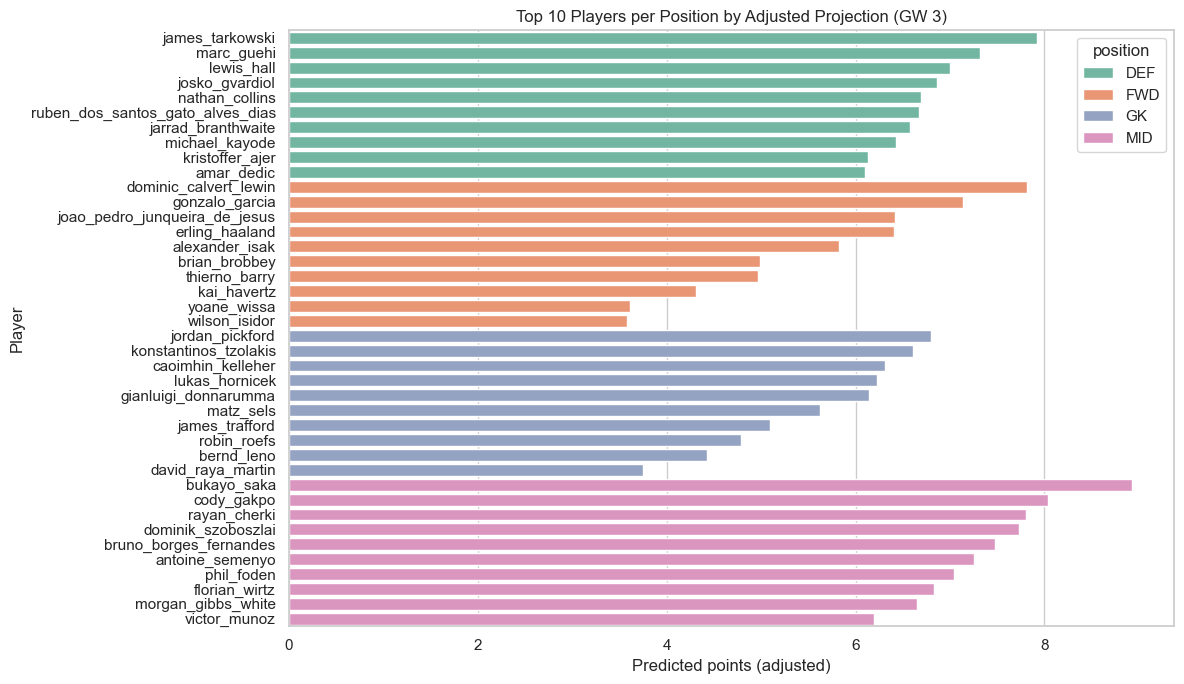

In [19]:
plot_df = (
    df_sorted
    .groupby('position', group_keys=False)
    .head(10)
    .copy()
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=plot_df.sort_values(['position', 'predicted_points_adj'], ascending=[True, False]),
    x='predicted_points_adj',
    y='full_name',
    hue='position',
    dodge=False,
    ax=ax,
    palette='Set2',
)
ax.set_title(f'Top 10 Players per Position by Adjusted Projection (GW {latest_gw})')
ax.set_xlabel('Predicted points (adjusted)')
ax.set_ylabel('Player')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'top10_by_position_gw{latest_gw}.png', dpi=200)

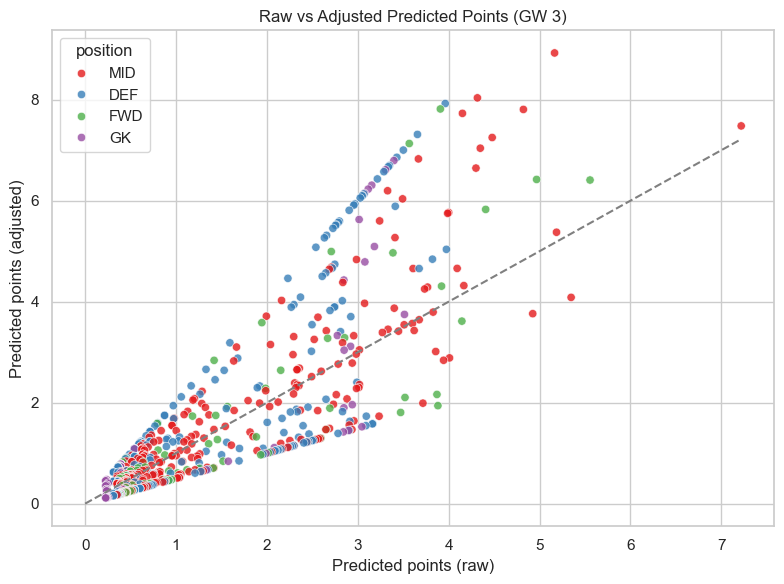

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df_sorted,
    x='predicted_points',
    y='predicted_points_adj',
    hue='position',
    alpha=0.8,
    ax=ax,
    palette='Set1',
)
ax.plot([0, df_sorted['predicted_points'].max()], [0, df_sorted['predicted_points'].max()], linestyle='--', color='grey')
ax.set_title(f'Raw vs Adjusted Predicted Points (GW {latest_gw})')
ax.set_xlabel('Predicted points (raw)')
ax.set_ylabel('Predicted points (adjusted)')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'raw_vs_adjusted_gw{latest_gw}.png', dpi=200)

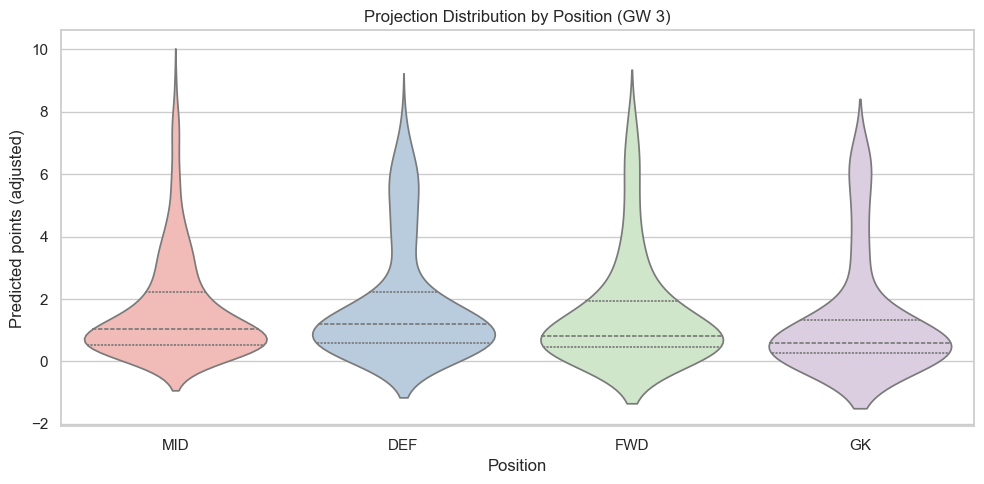

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=df_sorted,
    x='position',
    y='predicted_points_adj',
    inner='quartile',
    hue='position',
    legend=False,
    ax=ax,
    palette='Pastel1',
)
ax.set_title(f'Projection Distribution by Position (GW {latest_gw})')
ax.set_xlabel('Position')
ax.set_ylabel('Predicted points (adjusted)')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'distribution_by_position_gw{latest_gw}.png', dpi=200)

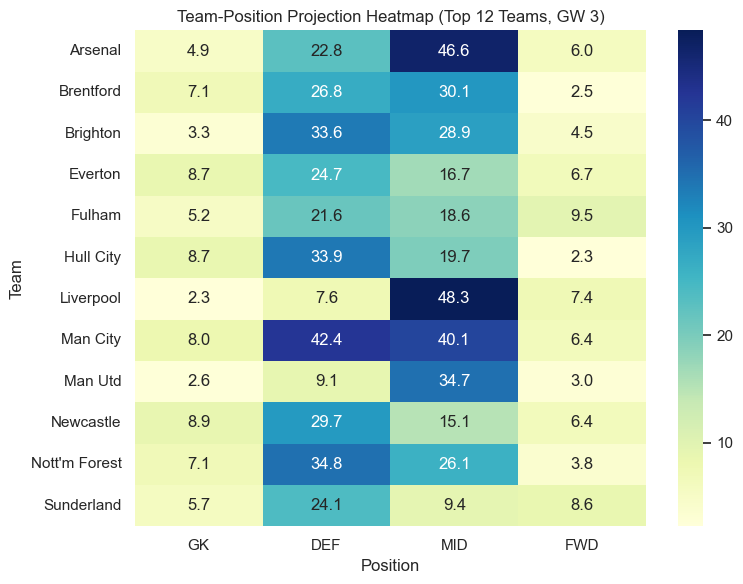

In [22]:
team_pos = (
    df_sorted
    .groupby(['team', 'position'], as_index=False)['predicted_points_adj']
    .sum()
)

team_total = team_pos.groupby('team', as_index=False)['predicted_points_adj'].sum()
top_teams = team_total.sort_values('predicted_points_adj', ascending=False).head(12)['team']
heat_df = team_pos[team_pos['team'].isin(top_teams)].pivot(index='team', columns='position', values='predicted_points_adj').fillna(0)
heat_df = heat_df[['GK', 'DEF', 'MID', 'FWD']]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heat_df, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax)
ax.set_title(f'Team-Position Projection Heatmap (Top 12 Teams, GW {latest_gw})')
ax.set_xlabel('Position')
ax.set_ylabel('Team')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'team_position_heatmap_gw{latest_gw}.png', dpi=200)

In [23]:
share_cols = ['full_name', 'position', 'team', 'owner_name', 'predicted_points', 'predicted_points_adj',
              'predicted_points_adj_3gw', 'predicted_points_adj_6gw', 'fixture_diff_index']
share_table = df_sorted[share_cols].head(25).copy()
share_table

,full_name,position,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,bukayo_saka,MID,Arsenal,Arthur,5.165318,8.926271,7.107086,6.742114,1.728116
1,cody_gakpo,MID,Liverpool,Rory D,4.316140,8.036667,6.523323,5.297302,1.862003
2,james_tarkowski,DEF,Everton,Marcus,3.962188,7.924376,7.490084,6.677743,2.000000
3,dominic_calvert_lewin,FWD,Leeds,Arthur,3.908525,7.817051,5.913534,5.174876,2.000000
4,rayan_cherki,MID,Man City,Marcus,4.822185,7.807617,6.011889,7.573070,1.619104
5,dominik_szoboszlai,MID,Liverpool,Rory D,4.151391,7.729905,6.274325,5.095102,1.862003
6,bruno_borges_fernandes,MID,Man Utd,Lucas,7.218612,7.481240,9.155660,8.859484,1.036382
7,marc_guehi,DEF,Man City,Dave,3.656438,7.312876,6.676736,6.006533,2.000000
8,antoine_semenyo,MID,Man City,Dave,4.478795,7.251633,5.583780,7.033788,1.619104
9,gonzalo_garcia,FWD,Fulham,Marcus,3.566374,7.132747,4.309141,3.539558,2.000000


In [24]:
if EXPORT_FIGURES:
    print(f'Saved figures to: {FIG_DIR.resolve()}')
else:
    print('Set EXPORT_FIGURES = True to save PNG charts for sharing.')

Set EXPORT_FIGURES = True to save PNG charts for sharing.


## Historical Backtest: Predicted vs Actual (All GWs)

In [25]:
import re
import sys
import requests

sys.path.append(str(Path('../..').resolve()))
from wrangle_data_funcs import clean_name

predictions_dir = Path('..') / 'predictions'
pred_files = sorted(predictions_dir.glob('predicted_gw[0-9]*.csv'))

gw_file_pairs = []
for file_path in pred_files:
    if file_path.name.endswith('_simple.csv'):
        continue
    match = re.search(r'predicted_gw(\d+)\.csv$', file_path.name)
    if match:
        gw_file_pairs.append((int(match.group(1)), file_path))

gw_file_pairs = sorted(gw_file_pairs, key=lambda x: x[0])
print(f'Found GW prediction files: {len(gw_file_pairs)}')

bootstrap = requests.get('https://fantasy.premierleague.com/api/bootstrap-static/', timeout=20).json()
name_by_element = {}
for elem in bootstrap['elements']:
    full_name = clean_name(f"{elem['first_name']}_{elem['second_name']}")
    name_by_element[elem['id']] = full_name

def load_actual_points_for_gw_from_api(gw):
    event_live = requests.get(f'https://fantasy.premierleague.com/api/event/{gw}/live/', timeout=20).json()
    rows = []
    for item in event_live.get('elements', []):
        element_id = item.get('id')
        full_name = name_by_element.get(element_id)
        if full_name is None:
            continue
        total_points = item.get('stats', {}).get('total_points', np.nan)
        rows.append({'full_name': full_name, 'actual_points': total_points})

    actual_gw_df = pd.DataFrame(rows)
    if actual_gw_df.empty:
        raise ValueError(f'No actual rows returned from FPL API for GW {gw}')

    return actual_gw_df

backtest_frames = []
skipped_gws = []
for gw, file_path in gw_file_pairs:
    pred_gw_df = pd.read_csv(file_path)
    if 'predicted_points_adj' not in pred_gw_df.columns:
        pred_gw_df['predicted_points_adj'] = pred_gw_df['predicted_points']

    try:
        actual_gw_df = load_actual_points_for_gw_from_api(gw)
    except Exception as exc:
        skipped_gws.append((gw, str(exc)))
        continue

    merged = pred_gw_df.merge(actual_gw_df, on='full_name', how='inner')
    if merged.empty:
        skipped_gws.append((gw, 'No name overlap between prediction and actual files'))
        continue

    merged['gw'] = gw
    backtest_frames.append(
        merged[['gw', 'full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'actual_points']]
    )

backtest_df = pd.concat(backtest_frames, ignore_index=True) if backtest_frames else pd.DataFrame()
print(f'Total merged player-GW rows: {len(backtest_df):,}')
if skipped_gws:
    print(f'Skipped GWs: {[gw for gw, _ in skipped_gws]}')

if not backtest_df.empty:
    backtest_df['error_raw'] = backtest_df['predicted_points'] - backtest_df['actual_points']
    backtest_df['error_adj'] = backtest_df['predicted_points_adj'] - backtest_df['actual_points']
    backtest_df['abs_error_raw'] = backtest_df['error_raw'].abs()
    backtest_df['abs_error_adj'] = backtest_df['error_adj'].abs()

backtest_df.head()

Found GW prediction files: 37
Total merged player-GW rows: 1,235
Skipped GWs: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]


,gw,full_name,position,team,predicted_points,predicted_points_adj,actual_points,error_raw,error_adj,abs_error_raw,abs_error_adj
0,2,aaron_anselmino,DEF,Chelsea,0.782188,0.391094,0,0.782188,0.391094,0.782188,0.391094
1,2,aaron_hickey,DEF,Brentford,1.512935,3.025870,1,0.512935,2.025870,0.512935,2.025870
2,2,abdoul_ouattara,DEF,Ipswich Town,0.947001,1.894002,1,-0.052999,0.894002,0.052999,0.894002
3,2,abdukodir_khusanov,DEF,Man City,3.211374,6.422748,2,1.211374,4.422748,1.211374,4.422748
4,2,abdul_fatawu,MID,Ipswich Town,2.414172,1.984991,4,-1.585828,-2.015009,1.585828,2.015009


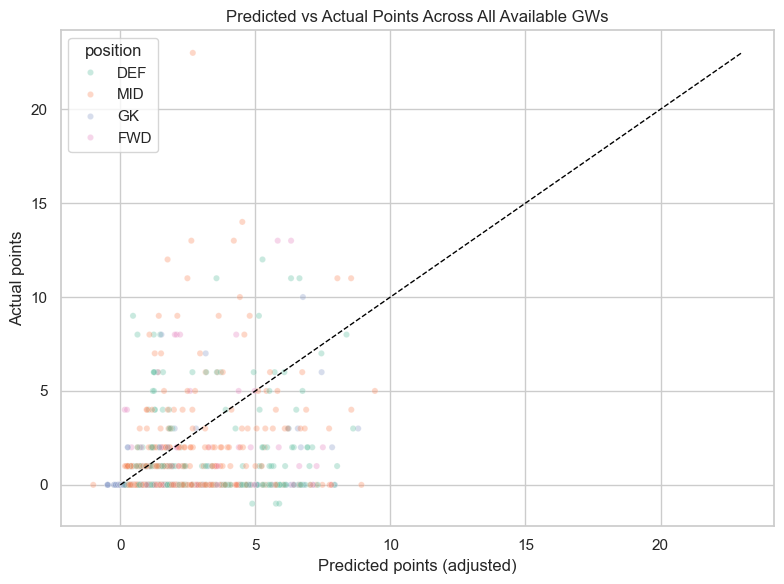

In [26]:
if backtest_df.empty:
    print('No backtest rows available. Check BACKTEST_YEAR and prediction files.')
else:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(
        data=backtest_df,
        x='predicted_points_adj',
        y='actual_points',
        hue='position',
        alpha=0.35,
        s=20,
        ax=ax,
        palette='Set2',
    )

    max_axis = max(backtest_df['predicted_points_adj'].max(), backtest_df['actual_points'].max(), 1)
    ax.plot([0, max_axis], [0, max_axis], linestyle='--', color='black', linewidth=1)
    ax.set_title(f'Predicted vs Actual Points Across All Available GWs')
    ax.set_xlabel('Predicted points (adjusted)')
    ax.set_ylabel('Actual points')
    plt.tight_layout()

    if EXPORT_FIGURES:
        fig.savefig(FIG_DIR / 'pred_vs_actual_all_gws.png', dpi=200)

,gw,mae_raw,mae_adj,rmse_raw,rmse_adj,corr_adj,n_players
0,2,1.269875,1.471447,2.139009,2.495223,0.453176,609
1,3,1.427391,1.653031,1.894240,2.414687,0.201989,626


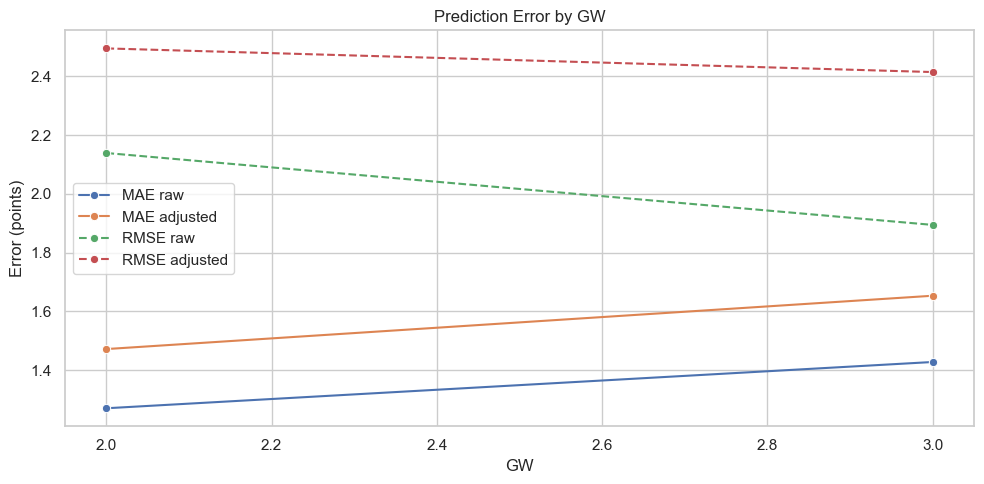

In [27]:
if backtest_df.empty:
    print('No backtest rows available. Skipping GW metric plots.')
else:
    gw_metrics = (
        backtest_df.groupby('gw', as_index=False)
        .agg(
            mae_raw=('abs_error_raw', 'mean'),
            mae_adj=('abs_error_adj', 'mean'),
            rmse_raw=('error_raw', lambda x: np.sqrt(np.mean(np.square(x)))),
            rmse_adj=('error_adj', lambda x: np.sqrt(np.mean(np.square(x)))),
            corr_adj=('predicted_points_adj', lambda x: x.corr(backtest_df.loc[x.index, 'actual_points'])),
            n_players=('full_name', 'count'),
        )
    )

    display(gw_metrics)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.lineplot(data=gw_metrics, x='gw', y='mae_raw', marker='o', label='MAE raw', ax=ax)
    sns.lineplot(data=gw_metrics, x='gw', y='mae_adj', marker='o', label='MAE adjusted', ax=ax)
    sns.lineplot(data=gw_metrics, x='gw', y='rmse_raw', marker='o', label='RMSE raw', ax=ax, linestyle='--')
    sns.lineplot(data=gw_metrics, x='gw', y='rmse_adj', marker='o', label='RMSE adjusted', ax=ax, linestyle='--')
    ax.set_title('Prediction Error by GW')
    ax.set_xlabel('GW')
    ax.set_ylabel('Error (points)')
    plt.tight_layout()

    if EXPORT_FIGURES:
        fig.savefig(FIG_DIR / 'prediction_error_by_gw.png', dpi=200)

### What Is corr_adj?

`corr_adj` is the Pearson correlation between `predicted_points_adj` and `actual_points` within each GW.

- `corr_adj` near `1.0`: your model ranked players very well that week.
- `corr_adj` near `0.0`: weak relationship between predictions and outcomes.
- `corr_adj` below `0.0`: rankings were directionally wrong that week.

This is most useful for judging ranking quality, not absolute error size.

,gw,corr_adj
0,2,0.453176
1,3,0.201989


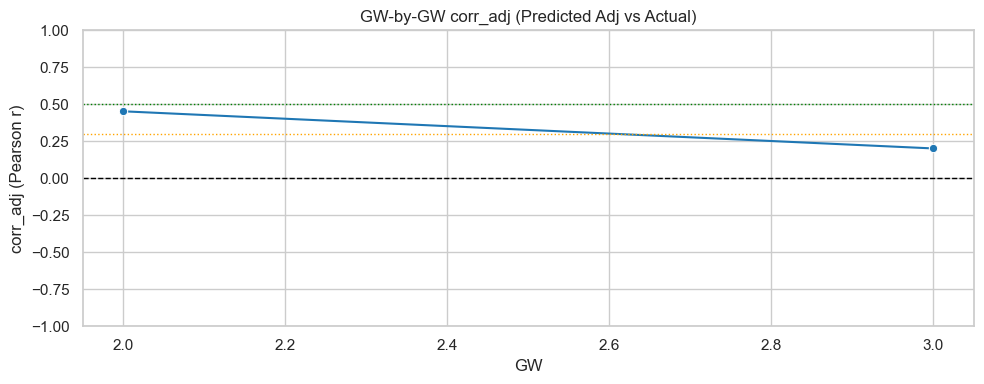

In [28]:
if backtest_df.empty:
    print('No backtest rows available. Skipping corr_adj plot.')
else:
    corr_plot_df = gw_metrics[['gw', 'corr_adj']].dropna().copy()

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.lineplot(data=corr_plot_df, x='gw', y='corr_adj', marker='o', ax=ax, color='#1f77b4')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.axhline(0.5, color='green', linestyle=':', linewidth=1)
    ax.axhline(0.3, color='orange', linestyle=':', linewidth=1)
    ax.set_ylim(-1, 1)
    ax.set_title('GW-by-GW corr_adj (Predicted Adj vs Actual)')
    ax.set_xlabel('GW')
    ax.set_ylabel('corr_adj (Pearson r)')
    plt.tight_layout()

    display(corr_plot_df)

    if EXPORT_FIGURES:
        fig.savefig(FIG_DIR / 'corr_adj_by_gw.png', dpi=200)